# Лабораторная работа

В данной работе мы с вами попробуем применить рекуррентные сети к задаче предсказания цены акций компании Microsoft.

В данном ноутбуке вы найдете частично готовый к применению код, некоторые элементы которого пропущены и вместо них стоит заглушка "\<ENTER YOUR CODE HERE>". Это означает, что вместо этой заглушки вам необходимо написать собственный код, решающий какую-то конкретную подзадачу. Детали вы найдете в комментариях около каждого из таких мест.
    
Давайте убедимся, что у нас установлены все необходимые библиотеки.

In [1]:
!pip install numpy matplotlib tensorflow

Для воспроизводимости зафиксируем генераторы случайных чисел.

In [3]:
seed_value = 0

import os

os.environ["PYTHONHASHSEED"] = str(seed_value)
os.environ["TF_CUDNN_DETERMINISTIC"] = "1"

import random
random.seed(seed_value)

import numpy as np
np.random.seed(seed_value)

import tensorflow as tf
tf.random.set_seed(seed_value)

Импортируем все необходимые библиотеки.

In [4]:
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

from sklearn.preprocessing import MinMaxScaler

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')

Для начала нам необходимо прочитать набор данных. Вместе с данным ноутбуком вы найдете файл MSFT_corrupted.csv. Прочитайте и запишите его в фрейм.

In [5]:
df_dirty = pd.read_csv("MSFT_corrupted.csv")

Давайте выведем первые несколько строк файла.

In [6]:
df_dirty.head()

,date,open,high,low,close,volume,Name
0,2015-11-18,53.00,53.98,52.9799,53.85,29710030,MSFT
1,2015-11-19,53.99,54.66,53.7810,53.94,28149228,MSFT
2,2015-11-20,54.25,54.30,53.2650,54.19,37147608,MSFT
3,2015-11-23,54.25,54.46,53.7500,54.19,28235918,MSFT
4,2015-11-24,53.92,54.44,53.5800,54.25,24600043,MSFT


Судя по названию файла, в нем могут присутствовать проблемы с данными. Давайте проверим данные на наличие NaN и каким-либо образом восстановим пропущенные значения.

In [8]:
# Смотрим, есть ли NaN
print(df_dirty.isna().sum())

df = df_dirty.copy()

df['date'] = pd.to_datetime(df['date'])

num_cols = ['open', 'high', 'low', 'close', 'volume']
df[num_cols] = df[num_cols].astype(float)
df[num_cols] = df[num_cols].interpolate(method='linear')

date      0
open      5
high      5
low       5
close     5
volume    0
Name      0
dtype: int64


В данной работе мы с вами будем предсказывать стоимость акции на момент закрытия дня (колонка 'close'). Давайте построим график этой колонки.

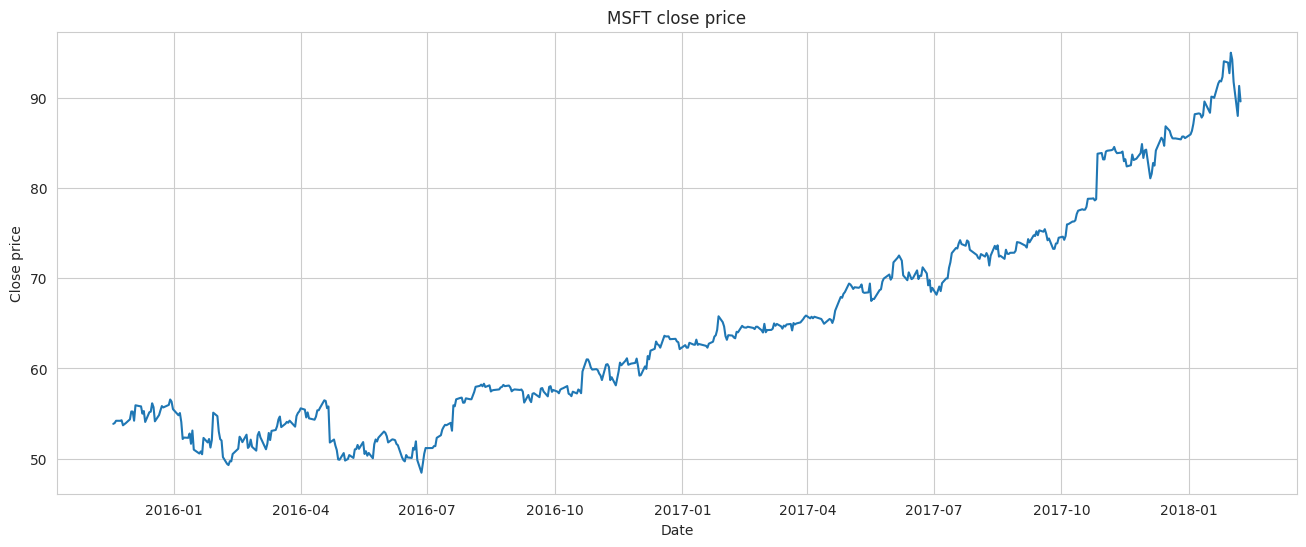

In [9]:
plt.figure(figsize=(16,6))
plt.plot(df['date'], df['close'])
plt.title('MSFT close price')
plt.xlabel('Date')
plt.ylabel('Close price')
plt.show()


Оставим в нашем датафрейме только необходимую нам колонку.

In [20]:
train_df = df[['close']].copy()

print(f"Форма данных для обучения: {train_df.shape}")
display(train_df.head())

EPOCHS = 10           # Количество эпох для обучения модели
DAYS = 10             # Количество дней для формирования входной последовательности
SPLIT_VALUE = 0.95    # Коэффициент разделения на тренировочную и тестовую выборку (95% / 5%)

print(f"\nПараметры обучения:")
print(f"  - Эпохи: {EPOCHS}")
print(f"  - Дней для последовательности: {DAYS}")
print(f"  - Коэффициент разделения: {SPLIT_VALUE}")

Форма данных для обучения: (559, 1)


,close
0,53.85
1,53.94
2,54.19
3,54.19
4,54.25



Параметры обучения:
  - Эпохи: 10
  - Дней для последовательности: 10
  - Коэффициент разделения: 0.95


Итак, теперь давайте подготовим все необходимое для начала обучения. Зададим глобальные константы - количества эпох, дней и коэффициент деления массива.

Определим константу для разделения массива на тренировочную и тестовую части.

In [21]:
training_data_len = int(len(train_df) * SPLIT_VALUE)
training_data_len

531

Далее с помощью MinMaxScaler'а приведем данные к значениям на отрезке \[0, 1]

In [24]:
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(train_df.values)

print(scaled_data.shape)
print(scaled_data[:5])

(559, 1)
[[0.11635895]
 [0.11829111]
 [0.12365822]
 [0.12365822]
 [0.12494633]]


Давайте создадим тренировочный набор данных. Набор будет выглядеть следующим образом: мы будем брать данные за последние X дней и формировать из этого вектор X, а вектор Y будет являться значением стоимости акции на следующий день

In [25]:
train_data = scaled_data[:training_data_len, :]

x_train = []
y_train = []

for i in range(DAYS, len(train_data)):
    x_train.append(train_data[i-DAYS:i])
    y_train.append(train_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

Создадим модель для предсказания. Первым слоем модели должен являться рекуррентный слой с соответствующей формой входного тензора, последним - полносвязный слой с единственным нейроном для предсказания результата.

In [26]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
model.add(LSTM(50, return_sequences=False))
model.add(Dense(25, activation='relu'))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

print("Архитектура модели:")
model.summary()

Архитектура модели:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_6 (LSTM)                   │ (None, 10, 50)         │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_7 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.fit(x_train, y_train, batch_size=1, epochs=EPOCHS)

Epoch 1/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 0.0050
Epoch 2/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.0016
Epoch 3/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.0014
Epoch 4/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0013
Epoch 5/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 0.0012
Epoch 6/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0011
Epoch 7/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 9.9711e-04
Epoch 8/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 8.7588e-04
Epoch 9/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 7.5064e-04
Epoch 10/10
521/521 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 6.4231e-04


Для тестирования нашей модели давайте таким же образом сформируем тестовый датасет.

In [28]:
test_data = scaled_data[training_data_len - DAYS:, :]

x_test = []
y_test = []

for i in range(DAYS, len(test_data)):
    x_test.append(test_data[i-DAYS:i])
    y_test.append(test_data[i, 0])

x_test = np.array(x_test)
y_test = np.array(y_test)


Давайте получим предсказания модели и визуализируем результат.

In [29]:
predictions = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 456ms/step


/tmp/ipykernel_8873/523100001.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions'] = scaler.inverse_transform(predictions)


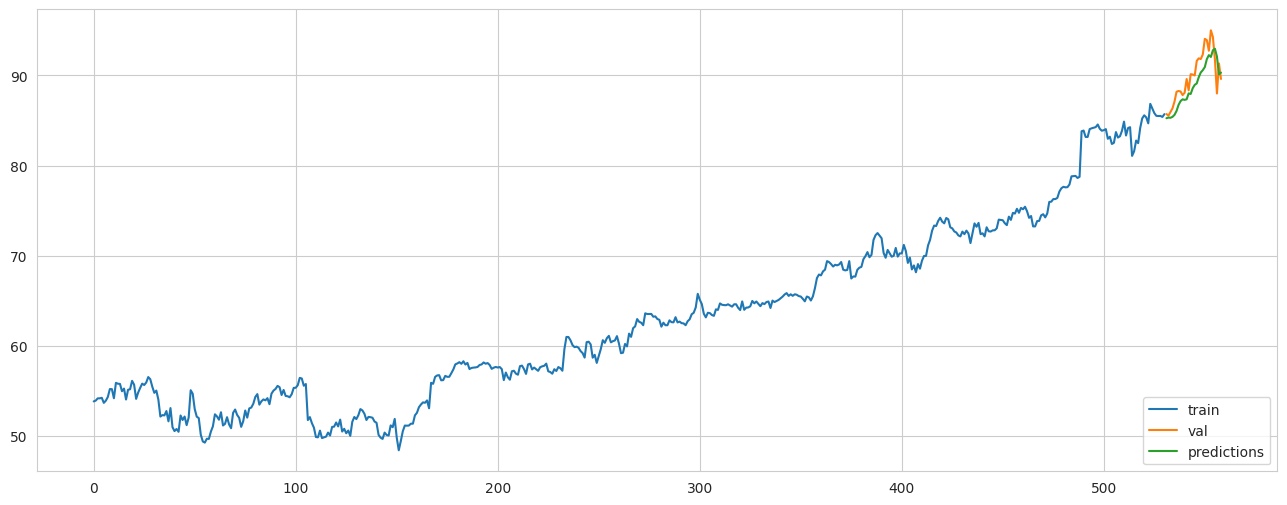

In [30]:
train = train_df[:training_data_len]
valid = train_df[training_data_len:]
valid['predictions'] = scaler.inverse_transform(predictions)
plt.figure(figsize=(16,6))
plt.plot(train['close'])
plt.plot(valid[['close', 'predictions']])
plt.legend(['train', 'val', 'predictions'], loc='lower right')

В качестве бейзлайна (т.е. базовой просто модели для сравнения) выберем step-1 модель. Данная модель для дня i просто берет значение дня i-1. Реализуйте такую модель и в массив prediction_step запишите ее результаты для тех же данных.

In [32]:
real_test = train_df['close'].values[training_data_len - 1:]
prediction_step = real_test[:-1].reshape(-1, 1)
predictions_step = prediction_step

print("real_test shape:", real_test.shape)
print("predictions_step shape:", predictions_step.shape)
print("Первые 5 значений real_test:", real_test[:5])
print("Первые 5 предсказаний step-1:", predictions_step[:5].ravel())

real_test shape: (29,)
predictions_step shape: (28, 1)
Первые 5 значений real_test: [85.71 85.72 85.54 85.95 86.35]
Первые 5 предсказаний step-1: [85.71 85.72 85.54 85.95 86.35]


In [33]:
assert predictions.shape == predictions_step.shape

Построим график нашей модели и step-1 модели.

/tmp/ipykernel_8873/1478130906.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_step'] = predictions_step


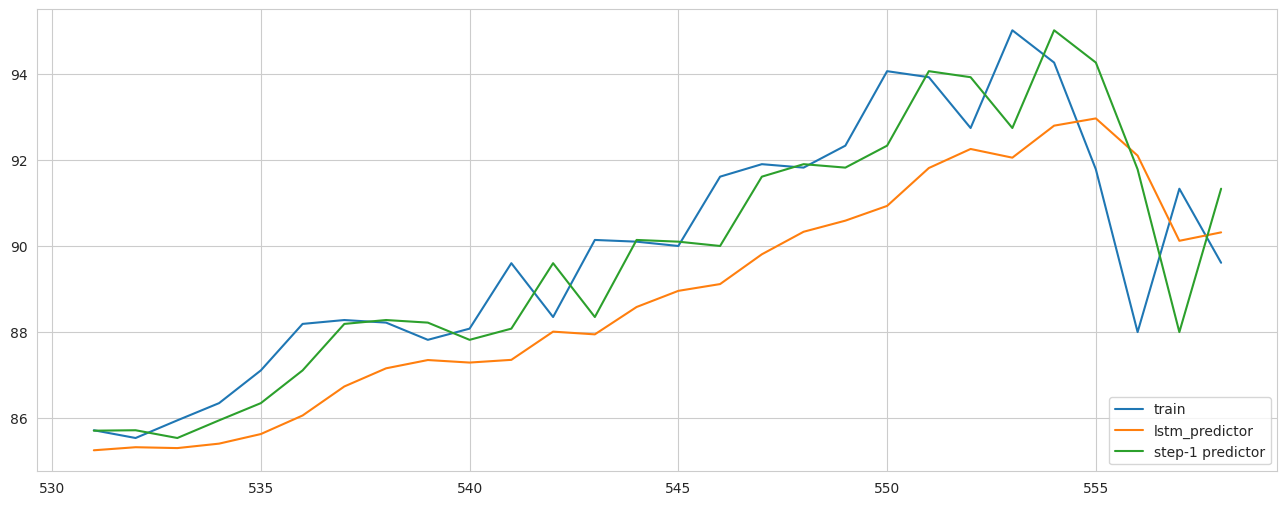

In [34]:
valid['predictions_step'] = predictions_step
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_step']])
plt.legend(['train', 'lstm_predictor', 'step-1 predictor'], loc='lower right')

Удалось ли вам добиться хороших результатов модели? Попробуйте поменять модель нейронной сети, количество слоев, и другие гиперпараметры.  

В процессе тестирования нашей модели мы, тем не менее, использовали "настоящие" данные каждый день для предсказания следующего дня. Давайте попробуем предсказать `len(valid)` дней (т.е. столько же, какова длина массива тестирования) обладая лишь данными на момент дня начала тестирования.  

Т.е. каждый шаг алгоритму необходимо подавать данные за последние DAYS дней, получать его предсказание и записывать в массив с данными как результат дня $i$. На следующем шаге в качестве данных уже будут данные за последние DAYS-1 дней и день $i$, а результат будет записан в день $i+1$ и так далее. Конечным итогом станет то, что мы сможем предсказать движение акций на несколько дней вперед.

In [35]:
x_test_independent = scaled_data[training_data_len - DAYS:training_data_len, 0].reshape(1, DAYS, 1)

for i in range(len(valid)):
    result = model.predict(x_test_independent, verbose=0)[0, 0]
    seq = x_test_independent.reshape(-1)
    seq = np.append(seq[1:], result)
    x_test_independent = seq.reshape(1, DAYS, 1)


Давайте построим график и посмотрим на результат, а также сравним его с результатом, когда нам известна настоящая информация за указанные дни.

/tmp/ipykernel_8873/2573778359.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['predictions_indep'] = scaler.inverse_transform(indep_preds)


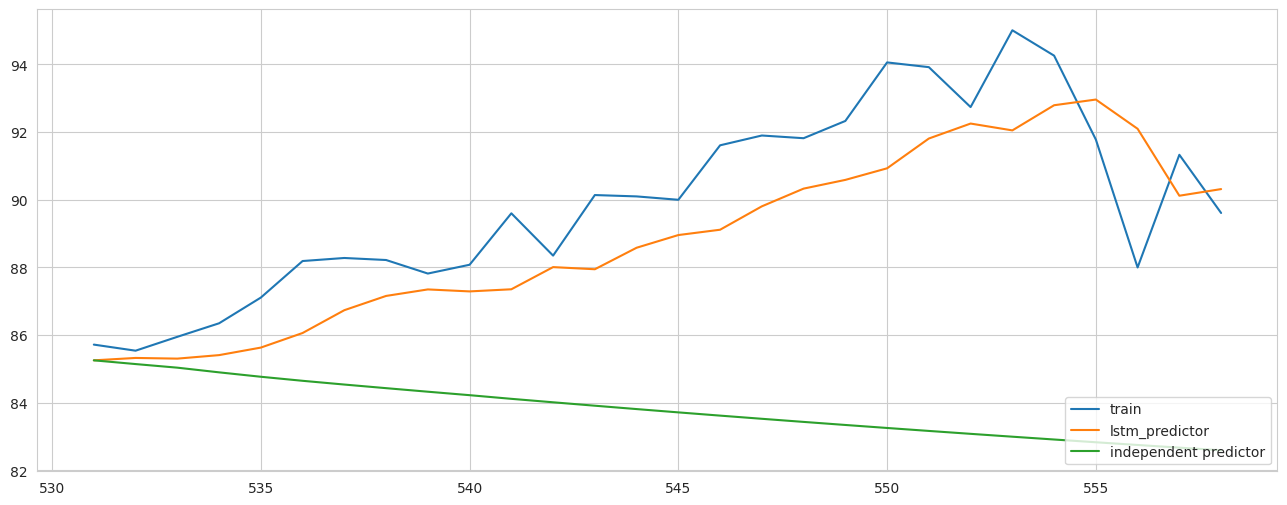

In [37]:
indep_preds = []
x_seq = scaled_data[training_data_len - DAYS:training_data_len, 0].reshape(1, DAYS, 1)
for i in range(len(valid)):
    pred = model.predict(x_seq, verbose=0)[0, 0]
    indep_preds.append(pred)

    seq = x_seq.reshape(-1)
    seq = np.append(seq[1:], pred)
    x_seq = seq.reshape(1, DAYS, 1)
indep_preds = np.array(indep_preds).reshape(-1, 1)
valid['predictions_indep'] = scaler.inverse_transform(indep_preds)
plt.figure(figsize=(16,6))
plt.plot(valid[['close', 'predictions', 'predictions_indep']])
plt.legend(['train', 'lstm_predictor', 'independent predictor'], loc='lower right')


Как можно заметить, результат оставляет желать лучшего. Рекуррентные модели склонны не учитывать тренд и фиксироваться на какой-либо точке.  

Вашим дальнейшим заданием будет следующее.  
В процессе анализа стоимости акций важным параметром является Moving Average - средняя стоимость акций за последние N дней. Вам необходимо вычислить MA за последние 7, 14 и 28 дней и добавить их как отдельные столбцы к тренировочным данным. После чего - натренировать новую нейронную сеть, которая будет получать MA 7, 14, 28 как входные данные и пытаться предсказывать их значения.

В конце точно так же сравните полученный результат с step-1 моделью и попробуйте построить предсказания из единственной точки. Сможет ли Moving Average исправить проблемы тренда за счет более гладких и усредненных результатов?

len(train_df): 559
len(ma_df): 532
   close        ma7       ma14       ma28
0  56.55  55.471429  55.341429  54.975357
1  56.31  55.782857  55.436429  55.063214
2  55.48  55.875714  55.451429  55.118214
3  54.80  55.797143  55.504286  55.140000
4  55.05  55.687143  55.497857  55.170714
x_train_ma: (495, 10, 3)
y_train_ma: (495,)
x_test_ma: (27, 10, 3)
y_test_ma: (27,)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_8 (LSTM)                   │ (None, 50)             │        10,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,851 (42.39 KB)

 Trainable params: 10,851 (42.39 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0047
Epoch 2/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0017
Epoch 3/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0015
Epoch 4/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0013
Epoch 5/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0012
Epoch 6/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0012
Epoch 7/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0011
Epoch 8/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.0010
Epoch 9/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 9.3100e-04
Epoch 10/10
495/495 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 8.7496e-04
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step


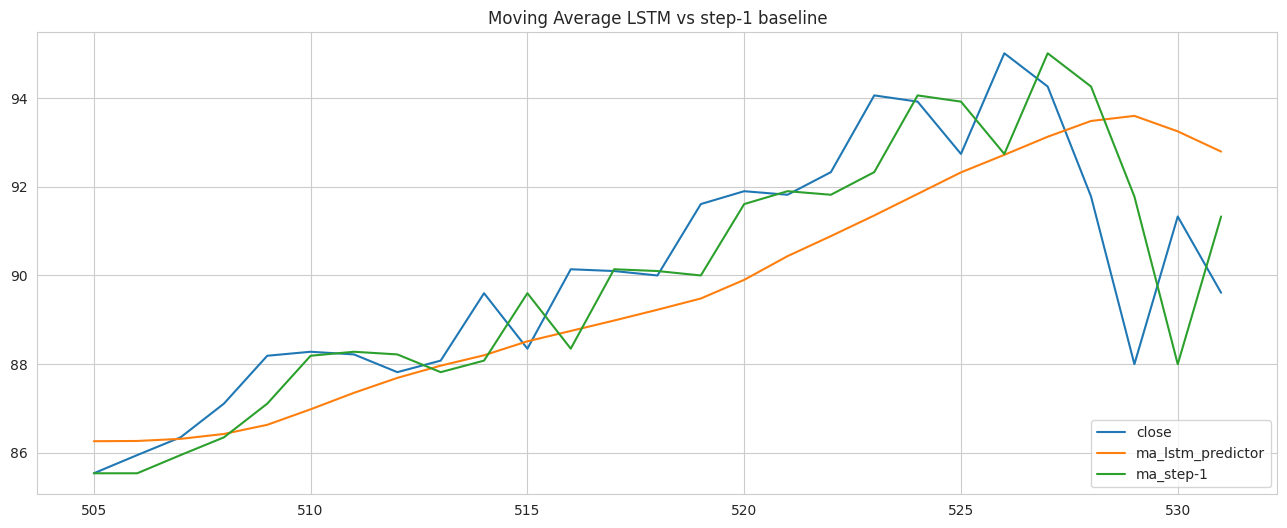

In [41]:
# === Moving Average LSTM: полный блок ===

# 1. MA-признаки
ma_df = train_df.copy()
ma_df['ma7']  = ma_df['close'].rolling(window=7).mean()
ma_df['ma14'] = ma_df['close'].rolling(window=14).mean()
ma_df['ma28'] = ma_df['close'].rolling(window=28).mean()
ma_df = ma_df.dropna().reset_index(drop=True)

print("len(train_df):", len(train_df))
print("len(ma_df):", len(ma_df))
print(ma_df.head())

# 2. Масштабирование признаков и цели
from sklearn.preprocessing import MinMaxScaler

features = ma_df[['ma7', 'ma14', 'ma28']].values
target   = ma_df[['close']].values

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

X_scaled = scaler_X.fit_transform(features)
y_scaled = scaler_y.fit_transform(target)

# 3. Делим на train/test и формируем последовательности
training_data_len_ma = int(len(ma_df) * SPLIT_VALUE)

train_X_raw = X_scaled[:training_data_len_ma]
train_y_raw = y_scaled[:training_data_len_ma]

test_X_raw  = X_scaled[training_data_len_ma - DAYS:]
test_y_raw  = y_scaled[training_data_len_ma - DAYS:]

def make_sequences(X_raw, y_raw, days):
    X_seq, y_seq = [], []
    for i in range(days, len(X_raw)):
        X_seq.append(X_raw[i-days:i, :])   # days × num_features
        y_seq.append(y_raw[i, 0])          # скаляр
    return np.array(X_seq), np.array(y_seq)

x_train_ma, y_train_ma = make_sequences(train_X_raw, train_y_raw, DAYS)
x_test_ma,  y_test_ma  = make_sequences(test_X_raw,  test_y_raw,  DAYS)

print("x_train_ma:", x_train_ma.shape)
print("y_train_ma:", y_train_ma.shape)
print("x_test_ma:", x_test_ma.shape)
print("y_test_ma:", y_test_ma.shape)

# 4. Модель на MA-признаках
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, LSTM, Dense

model_ma = Sequential()
model_ma.add(Input(shape=(DAYS, 3)))
model_ma.add(LSTM(50, return_sequences=False))
model_ma.add(Dense(1))

model_ma.compile(optimizer='adam', loss='mean_squared_error')
model_ma.summary()

history_ma = model_ma.fit(
    x_train_ma, y_train_ma,
    batch_size=1,
    epochs=EPOCHS,
    verbose=1
)

# 5. Предсказания и обратное преобразование
predictions_ma_scaled = model_ma.predict(x_test_ma)
predictions_ma = scaler_y.inverse_transform(predictions_ma_scaled)
y_test_ma_real = scaler_y.inverse_transform(y_test_ma.reshape(-1, 1))

# 6. step-1 бейзлайн для того же периода
valid_ma = ma_df[training_data_len_ma:]  # тестовый отрезок
valid_ma = valid_ma.copy()

real_close_ma = valid_ma['close'].values
predictions_step_ma = real_close_ma[:-1].reshape(-1, 1)
# чтобы длины совпали: для первой точки берём её же цену
predictions_step_ma = np.vstack([real_close_ma[0], predictions_step_ma]).reshape(-1, 1)

# 7. График MA-модели vs step-1
valid_ma['predictions_ma'] = predictions_ma
valid_ma['predictions_step'] = predictions_step_ma

plt.figure(figsize=(16,6))
plt.plot(valid_ma[['close', 'predictions_ma', 'predictions_step']])
plt.legend(['close', 'ma_lstm_predictor', 'ma_step-1'], loc='lower right')
plt.title('Moving Average LSTM vs step-1 baseline')
plt.show()


# Выввод

Модель на Moving Average не точно  воспроизводит все локальные колебания цены, но даёт сглаженное предсказание, которое следует за реальным трендом и растёт рядом с ним.